# Clasificación PCA, Validación Cruzada

In [ ]:
# Resolver ruta de Bases de datos en Colab o local
import os
import sys
import subprocess
from pathlib import Path

REPO_NOTEBOOKS = "https://github.com/AdanReyes2407/Notebooks_NM_ML.git"

def _is_colab():
    return "google.colab" in sys.modules

def _ensure_repo_clone(repo_url=REPO_NOTEBOOKS, target=Path('/content/Notebooks_NM_ML')):
    if _is_colab() and not target.exists():
        subprocess.run(["git", "clone", repo_url, str(target)], check=True)

def _resolve_data_dir():
    _ensure_repo_clone()
    candidates = [
        Path('/content/Notebooks_NM_ML/Bases de datos'),
        Path.cwd() / 'Bases de datos',
        Path.cwd().parent / 'Bases de datos',
        Path('/content/Bases de datos'),
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

DATA_DIR = _resolve_data_dir()
print('DATA_DIR =', DATA_DIR)


Se usará para la clasificación una base de datos de un acelerómetro de un smartphone que reconoce si el ususario camina, está sentado, esta de pie, está acostado, camina hacia arriba o camiona hacia abajo

Esta es una descripción más detallada en inglés de la base de datos:

"The experiments have been carried out with a group of 30 volunteers within an age bracket of 19-48 years. Each person performed six activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING) wearing a smartphone (Samsung Galaxy S II) on the waist. Using its embedded accelerometer and gyroscope, we captured 3-axial linear acceleration and 3-axial angular velocity at a constant rate of 50Hz. The experiments have been video-recorded to label the data manually.

The sensor signals (accelerometer and gyroscope) were pre-processed by applying noise filters and then sampled in fixed-width sliding windows of 2.56 sec and 50% overlap (128 readings/window). The sensor acceleration signal, which has gravitational and body motion components, was separated using a Butterworth low-pass filter into body acceleration and gravity. The gravitational force is assumed to have only low frequency components, therefore a filter with 0.3 Hz cutoff frequency was used. From each window, a vector of features was obtained by calculating variables from the time and frequency domain. See 'features_info.txt' for more details."


## Importación de módulos

In [1]:
%matplotlib inline
from pylab import *
import pandas as pd
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix

## Importación de los datos

#### Recuperación de los features

In [11]:
# TO DO
# Pista: Completa este bloque preservando el flujo PCA + validaci?n cruzada del notebook original.
# Referencia original de la celda: # Ruta de la base UCI-HAR
# Escribe aqu? tu implementaci?n y conserva los nombres de variables del flujo.
raise NotImplementedError("Completa esta celda")


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
5,0.277199,-0.010098,-0.105137,-0.997335,-0.990487,-0.995420,-0.997627,-0.990218,-0.995549,-0.942469,...,0.019953,-0.545410,-0.844619,0.082632,-0.143439,0.275041,-0.368224,-0.849632,0.184823,-0.042126
6,0.279454,-0.019641,-0.110022,-0.996921,-0.967186,-0.983118,-0.997003,-0.966097,-0.983116,-0.940987,...,0.145844,-0.217198,-0.564430,-0.212754,-0.230622,0.014637,-0.189512,-0.852150,0.182170,-0.043010
7,0.277432,-0.030488,-0.125360,-0.996559,-0.966728,-0.981585,-0.996485,-0.966313,-0.982982,-0.940987,...,0.136382,-0.082307,-0.421715,-0.020888,0.593996,-0.561871,0.467383,-0.851017,0.183779,-0.041976
8,0.277293,-0.021751,-0.120751,-0.997328,-0.961245,-0.983672,-0.997596,-0.957236,-0.984379,-0.940598,...,0.314038,-0.269401,-0.572995,0.012954,0.080936,-0.234313,0.117797,-0.847971,0.188982,-0.037364
9,0.280586,-0.009960,-0.106065,-0.994803,-0.972758,-0.986244,-0.995405,-0.973663,-0.985642,-0.940028,...,0.267383,0.339526,0.140452,-0.020590,-0.127730,-0.482871,-0.070670,-0.848294,0.190310,-0.034417


#### Recuperación de las actividades (targets)

In [12]:
# Liste des classes correspond à chaque personne.
# Lista de clases corresponde a cada persona
# On associe à un nombre à chaque activité.
# se le asocia a cada actividad un número para identificarla más fácilmente

data_path = votre_path + "train\\y_train.txt"
activity  = pd.read_csv(data_path,delim_whitespace=True,header=None)
activity  = activity.values[:,0] -  1 # queremos comenzar desde cero y se empezaba desde 1
activity_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING'];

#### Recuperación de los subjects

In [14]:
data_path = votre_path + "train\\subject_train.txt"
sujet = pd.read_csv(data_path,delim_whitespace=True,header=None)
sujet = sujet.values[:,0]
print(sujet)
print(sujet.shape)

## Standarización de los features: Así es más fácil tratar a los datos después PCA (estadnadriza al centro y varianza uno)
features_nor = preprocessing.scale(activity_features)

[ 1  1  1 ... 30 30 30]
(7352,)


## Anállisis de Componentes principales para los features

El análisis de componentes principales es un métodod de reducción de dimensión y de compresión de datos. Consiste en encontrar un sous espacio vectorial de dimensión $q$ que aproxime lo mejor posible un conjunto d epuntos en $\mathbb R^d$. Todo esto en el sentido de la proyección euclidia en ese espacio.

Las direcciones del sus espacio vectorial aproximante pueden ser vistas como nuevas variables, que se expresan como combinaciones lineales de las variables iniciales. Estas nuevas variables se llaman **Componentes principales**, son dirigidas en las primeras direcciones propias de la matriz de covarianza empírica de los datos.

![analyse en composantes principales](http://www.nlpca.org/fig_pca_principal_component_analysis.png)

Ahora trazaremos el conjunto de datps de las dos primeras componentes del PCA distingueindo las 6 actividades para constatar que hay mucho recubrimeinto entre las clases en estas dos primeras componentes, es decir, que es dificil distinguir entre ellas solo con dos variables, enecsitaremos más.  

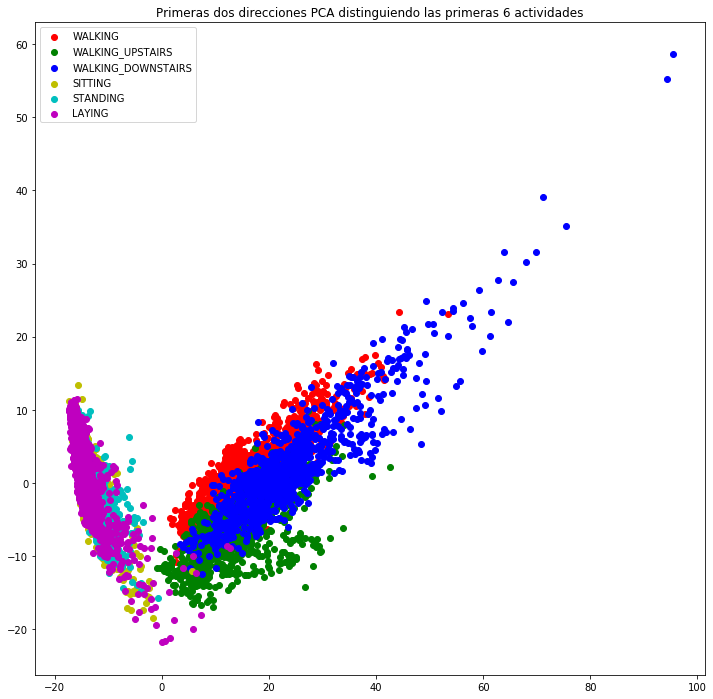

In [15]:
# TO DO
# Pista: Completa este bloque preservando el flujo PCA + validaci?n cruzada del notebook original.
# Referencia original de la celda: from sklearn.decomposition import PCA
# Escribe aqu? tu implementaci?n y conserva los nombres de variables del flujo.
raise NotImplementedError("Completa esta celda")


## Problema de clasificaión con 2 clases

Par simplificar todod, hagamos tomemos únicamente las clases 3 y 4 y hagamos el problema.

In [17]:
# utilizaremos las features estandarizadas
n = features_nor.shape[0]
index_act34 = [i for i in range(n) if activity[i]==3 or activity[i]==4] ## encontarr los índices necesarios 
activity34 = [activity[i] for i in index_act34] # encontrar las actividades en la matriz
features34 = [features_nor[i] for i in index_act34] #igual para las features

## Preselección de features para reducir la dimesnión (screening)

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif
Selec = SelectKBest(k=100) # selecciona las 100 features con el k csore más alto
features34 = Selec.fit_transform(features34, activity34)
# el fit_transform hace eso ajusta el modelo y te lo transforma
# debes ponerl tanto las variables X (feature) y Y (activities)

## ajustar métodos de clasificación clásicos

In [19]:
# Bayes Ingénuo.

from sklearn.naive_bayes import GaussianNB 
gnb = GaussianNB()
gnb.fit(features34, activity34)

# K vecinos más cercanos.

from sklearn import neighbors
nn = neighbors.KNeighborsClassifier(n_neighbors = 10)
nn.fit(features34, activity34)

# Regresión logística.

from sklearn import linear_model
logit_lasso = linear_model.LogisticRegression(random_state=0, penalty = 'l1', solver='saga', multi_class='multinomial', max_iter = 10000)
logit_lasso.fit(features34, activity34) ;
logit_ridge = linear_model.LogisticRegression(random_state=0, penalty = 'l2', solver='saga', multi_class='multinomial', max_iter = 10000)
logit_ridge.fit(features34, activity34) ;

#Penaliodad 1 es la lasso de orden uno (valor absoluto)
# la 2 es cuadrática y se llama ridge
# Tomamos max_iter = 10000 para evitar que no converja.

### Estimación de los errores de cada uno de los métodos

Vamos a calculas el error pero con todos los datos (aún no hacemos ningun grupo test o train). Veremos que los errores son bajitos y están mal calculados.

In [ ]:
# TO DO
# Pista: Completa este bloque preservando el flujo PCA + validaci?n cruzada del notebook original.
# Referencia original de la celda: # Error = 1 - score
# Escribe aqu? tu implementaci?n y conserva los nombres de variables del flujo.
raise NotImplementedError("Completa esta celda")


Hagamos lo que se debió hacer desde el inicio: Train/test

In [ ]:
# TO DO
# Pista: Completa este bloque preservando el flujo PCA + validaci?n cruzada del notebook original.
# Referencia original de la celda: from sklearn import model_selection
# Escribe aqu? tu implementaci?n y conserva los nombres de variables del flujo.
raise NotImplementedError("Completa esta celda")


## Vecinos más cercanos

In [ ]:
PPV = neighbors.KNeighborsClassifier(n_neighbors = 10)
PPV.fit(features_train, activity_train)
print("Error estiamdo del método k vecinos más cercanos para esos set train / test : ", 1 - PPV.score(features_test, activity_test))

In [ ]:
# TO DO
# Pista: Completa este bloque preservando el flujo PCA + validaci?n cruzada del notebook original.
# Referencia original de la celda: ## vamos ahora a hacer esto 100 veces para ver que tan concentrado está el error
# Escribe aqu? tu implementaci?n y conserva los nombres de variables del flujo.
raise NotImplementedError("Completa esta celda")


### Trazamos ahora una curva del error en función de k

In [ ]:
erreur_train_test = [] # lista que va a contener los errore spromedio.

for k in range(1,16) :
    score_train_test = [] # Lista de scores para cada set train/test.
    for simu in range(20) :
        features_train, features_test, activity_train, activity_test = model_selection.train_test_split(features34, activity34, test_size=0.40)
        nn_train_test = neighbors.KNeighborsClassifier(n_neighbors = k)
        nn_train_test.fit(features_train, activity_train)
        score_train_test.append(nn_train_test.score(features_test, activity_test)) # añadir a la lista el score obtenido
    score_train_test = np.array(score_train_test) # pasar la lista a array
    erreur_train_test += [np.mean(1 - score_train_test)] # error promedio
    
# Gráfica.
    
plt.figure()
plt.plot(range(1,16), erreur_train_test)
plt.xlabel('Número de vecinos')
plt.ylabel('Error promedio obtenido')
plt.title('Erro obtenido en función del número de vecinos elegido') ;

En realidad cuando tenemos varios modelos y necesitamso elegir debemos tener 3 sets:
- Train: Utilizado para construir loe modelos
- Validación Utilizado para elegir un modelo.
- Test: Para evaluar el desespeño del modelo elegido

Esto es importante cuando queremos comparar dos métodos que hacen intervenir un reglage de paraémtros: en nuestro caso el número de vecinos. Veámoslo:

In [ ]:
# train (50 %) / valid (25 %) / test (25 %).

features_train, features_valid, activity_train, activity_valid = model_selection.train_test_split(features34, activity34, test_size=0.50)
features_test, features_valid, activity_test, activity_valid = model_selection.train_test_split(features_valid, activity_valid, test_size=0.50)

# Construcción de los modelos.

erreur_train_valid = [] # lista para los errores medios para cada valor de k
nn_train_valid = []     # Lista de modelos.
score_train_valid = [] # Lista de scores para el settrain / test.

for k in range(1,16) :

    nn_train_valid += [neighbors.KNeighborsClassifier(n_neighbors = k)] #almacenar el modelo
    nn_train_valid[k-1].fit(features_train, activity_train) #ajustar el modelo
    score_train_valid.append(nn_train_valid[k-1].score(features_valid, activity_valid)) #obtener el score

# Elección del modelo.

nn = nn_train_valid[score_train_test.index(max(score_train_valid))]

# Evaluación del desempeño del modelo elegido.

cnf_matrix_nn_test = confusion_matrix(activity_test, nn.predict(features_test))

print("\n Matriz de confusión obtenida para los vecinos más cercanos elegido con la funcion gridSearchCV : \n \n", cnf_matrix_nn_test.astype('float') / cnf_matrix_nn_test.sum(axis=1).reshape(-1,1))

## Estimación del resigo (error) por validación cruzada

Validación cruzada del tipo **k-fold**.

La idea principal es de que cada observación haga el papel de train y de validación.

El principio cosntsite a hacer particiones aleatorias de los datos $D=(\mathbf{x}_i,y_i)_{1\leq i\leq N} $ 
en $K$ bloques disjuntos de tallas comparables:
$D^1,\ldots,D^K$. Tomamos generalmente $K=5$ o $10$. El método **leave-one-out (Loo)** corresponde a $K=N-1$. 

Estimamos la calidad de un predictor  $\hat f$ de la manera siguiente:

- $ \forall k \in \{1,\dots, K\}$, construimos un predictor $\hat f^k$ (del mismo tipo que $\hat f$) usando el set train $D^{-k} := D\setminus D^k$ ;
- Estimamos el riesgo del predictor $\hat f$ usando:   
$$
\frac{1}{N}\sum_{k=1}^K\sum_{\mathbf{x}_i\in D^k} \ell(\hat f^k(\mathbf{x}_i),y_i),
$$
done $\ell$ es la perdida (penalidad) utilizada.

Construimos la misma cantidad de predictores como hay de bloques en el conjunto de aprendizaje. Cada predictor es evaluado en los elemntos del bloque que no ha sido utilizado para el aprendizaje (y que entonces juega el rol de validación)

Cuando uno desea ajustar un parpametro utilizando validación cruzada, pro ejemplo el numero de vecinos $k$ para knn, procedemos como sigue:

- Evaluamos los performances de los predictores como explicado anteriormente.
- Se determina el valor optimal del parámetro
- Construimos finalmente un predictor para el parámetro elegido, utilizando como base de aprendizaje a todos los datos.

**Comparación entre LOO y K folds**
- LOO cuesta más a la computadora.
- La varianza del error obtenido por LOO es generalmente maás elevada que por k pequeño.
- Si el error decrece muy rápiudo con $n$ (número de datos) el k-fold con k péqueño puede sobreestimatr el error.
- En general se recomiedno k- fold con k=5 o 10

## Error con 10-fold

In [ ]:
# TO DO
# Pista: Completa este bloque preservando el flujo PCA + validaci?n cruzada del notebook original.
# Referencia original de la celda: nn_val_croisee = neighbors.KNeighborsClassifier(n_neighbors = 10)
# Escribe aqu? tu implementaci?n y conserva los nombres de variables del flujo.
raise NotImplementedError("Completa esta celda")


## Error con LOO

In [ ]:
loo = model_selection.LeaveOneOut()

scores = [] # Lista de scores para cada iteración.

for train_index, test_index in loo.split(features34) :
    # iteraciones sobre los índices a elegir para el set train y test
    features_train = []
    features_test  = []
    activity_train = []
    activity_test  = []
    for i in train_index : # Juntamos uno por uno los elementos del set train
        features_train += [features34[i]]
        activity_train += [activity34[i]]
    features_test += [features34[test_index[0]]] # en el set test solo hay un elemento
    activity_test += [activity34[test_index[0]]] # en el set test solo hay un elemento
    nn_train_test = neighbors.KNeighborsClassifier(n_neighbors = 10)
    nn_train_test.fit(features_train, activity_train)
    scores += [nn_train_test.score(features_test, activity_test)]
    
erreur = 1 - np.array(scores)
print("Erreur moyenne : \n", np.mean(erreur))

## Selección del número de vecinos por 10-fold

In [ ]:
liste_scores = []

for nb_voisins in range(1,16) : # veremos el score promeido obtenido por cruzada para cada k 
    nn_val_croisee = neighbors.KNeighborsClassifier(n_neighbors = nb_voisins)
    scores = model_selection.cross_val_score(nn_val_croisee, features34, activity34, cv=10)
    liste_scores += [mean(scores)]

# Elegimso el k con mayor score para 10-fold.
    
print("Nombre de plus proches voisins sélectionné par validation croisée 10 fold :", liste_scores.index(max(liste_scores)))

In [ ]:
# construimos el clasificador para vecinos más cercanos para todos los datos
nn_val_croisee = neighbors.KNeighborsClassifier(n_neighbors = liste_scores.index(max(liste_scores)))
nn_val_croisee.fit(features34, activity34) ;

## La función GridSearchCV

Esta función hace el la validación cruzda para varios valores de k

In [ ]:
# TO DO
# Pista: Completa este bloque preservando el flujo PCA + validaci?n cruzada del notebook original.
# Referencia original de la celda: from sklearn.model_selection import GridSearchCV
# Escribe aqu? tu implementaci?n y conserva los nombres de variables del flujo.
raise NotImplementedError("Completa esta celda")


si la máquina lo permite se pueden utilzar en paralelo

In [ ]:
# Utilisación de 2 núcleos en paralelo.

start = time()
nnGrid = GridSearchCV(neighbors.KNeighborsClassifier(), tuned_parameters, cv=5, n_jobs = 2)
nnGrid.fit(features34, activity34)
print(str(time() - start)+ " sec")
print(nnGrid.best_params_)

## Clasificación Multiclase

Se sigue la misma estrategia

In [ ]:
Selec = SelectKBest(f_classif, k = 20)
features_all_activities = Selec.fit_transform(activity_features, activity)

In [ ]:
# TO DO
# Pista: Completa este bloque preservando el flujo PCA + validaci?n cruzada del notebook original.
# Referencia original de la celda: gnb = GaussianNB()
# Escribe aqu? tu implementaci?n y conserva los nombres de variables del flujo.
raise NotImplementedError("Completa esta celda")


In [ ]:
nn = neighbors.KNeighborsClassifier(n_neighbors = 13, weights = "uniform")
scores = model_selection.cross_val_score(nn, features_all_activities, activity, cv = 10)
print("Erreur pour chaque bloc : \n", 1 - scores)
print("\n Erreur moyenne : \n", 1 - mean(scores))

In [ ]:
# Utilzación de grid search para 5-fold

tuned_parameters = {'n_neighbors': range(2,20)}
nnGrid = GridSearchCV(nn, tuned_parameters, cv=5, n_jobs = 2)
nnGrid.fit(features_all_activities, activity)
print(nnGrid.best_params_)

# Découpage train / test.

features_train, features_test, activity_train, activity_test = model_selection.train_test_split(features_all_activities, activity, test_size=0.40)

PPV_Python = neighbors.KNeighborsClassifier(n_neighbors = nnGrid.best_params_['n_neighbors']) # Nuevo modelo con el k elegido
PPV_Python.fit(features_train, activity_train)
cnf_matrix_PPV_test = confusion_matrix(activity_test, PPV_Python.predict(features_test))

print("\n Matriz de confusion obtenida con la funcion gridSearchCV : \n \n", cnf_matrix_PPV_test.astype('float') / cnf_matrix_PPV_test.sum(axis=1).reshape(-1,1))